# Behaviour Analyses — Mixed Models

In [96]:
from pymer4.models import lmer, glmer
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm
import warnings

sns.set(font_scale=1.3, style="ticks")
plt.rcParams["figure.dpi"] = 100


In [97]:
# ── Cell 2: Load data ───────────────────────────────────────────────────────
data_path = "/Users/martu/Documents/TFG_MARTINA/dataset/CJ_EEG.csv"
all_df = pd.read_csv(data_path)
print(f"Dataset loaded: {all_df.shape[0]} rows, {all_df.shape[1]} columns")
all_df.head(3)

Dataset loaded: 6600 rows, 36 columns


,exp_ID,npar,subj,nblock,ntrial,nrep,cond-1,trial_type,rDV,deci-3,...,d6,o1,o2,o3,o4,o5,o6,metad,metad_3%,metad_97%
0,CJ_EEG,1,s01,0,0,0,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
1,CJ_EEG,1,s01,0,0,1,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51
2,CJ_EEG,1,s01,0,0,2,0,repeat,-0.203974,0,...,-0.944496,2.697,0.715,1.903,1.576,1.214,1.549,0.086,-0.345,0.51


In [98]:
# ── Cell 3: Preprocessing ───────────────────────────────────────────────────
df = all_df.copy()

df["cond"]    = df["cond"].replace({-1: 0})
df["correct"] = df["correct"].replace({-1: 0})
df["switch"]  = (df["deci"] != df["deci-1"]).astype(int)

median_confi   = df["confi"].median()
df["conf_lvl"] = np.where(df["confi"] >= median_confi, "H", "L")

df = df.sort_values(["subj", "nblock", "ntrial", "nrep"]).reset_index(drop=True)
df["confi-1"]   = df.groupby(["subj", "nblock", "ntrial"])["confi"].shift(1)
df["correct-1"] = df["corr-1"]

df["nrep_f"]    = df["nrep"].astype(str)
df["is_repeat"] = (df["trial_type"] == "repeat").astype(int)
df["deci1_c"]   = df["deci-1"] - 0.5
df["rDV_z"]     = df.groupby("subj")["rDV"].transform(
    lambda x: (x - x.mean()) / x.std())
df["metad_z"]   = (df["metad"] - df["metad"].mean()) / df["metad"].std()

print(f"cond      → {sorted(df['cond'].unique())}")
print(f"correct   → {sorted(df['correct'].unique())}")
print(f"switch    → {sorted(df['switch'].unique())}")
print(f"is_repeat → {sorted(df['is_repeat'].unique())}")
print(f"\nNaN confi-1  : {df['confi-1'].isna().sum()}")
print(f"NaN correct-1: {df['correct-1'].isna().sum()}")
print(f"\nTotal rows   : {len(df)}")
print(f"Participants: {df['subj'].nunique()}")

cond      → [np.int64(0), np.int64(1)]
correct   → [np.int64(0), np.int64(1)]
switch    → [np.int64(0), np.int64(1)]
is_repeat → [np.int64(0), np.int64(1)]

NaN confi-1  : 2200
NaN correct-1: 0

Total rows   : 6600
Participants: 25


In [99]:
# ── Cell 4: RT filter ───────────────────────────────────────────────────────
def RT_filter(x, sd=4):
    return x[x["RT"] < x["RT"].mean() + sd * x["RT"].std()]

df_rt = df.groupby("npar", group_keys=False).apply(RT_filter, sd=4)
df_rt = df_rt.reset_index(drop=True)

print(f"Trials before filter : {len(df)}")
print(f"Trials after filter: {len(df_rt)}")
print(f"Trials removed       : {len(df)-len(df_rt)} ({(len(df)-len(df_rt))/len(df)*100:.1f}%)")

Trials before filter : 6600
Trials after filter: 6537
Trials removed       : 63 (1.0%)


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_95728/73687468.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rt = df.groupby("npar", group_keys=False).apply(RT_filter, sd=4)


In [100]:
# ── Cell 5: LMM on RT ───────────────────────────────────────────────────────
# Model: RT ~ nrep * is_repeat + (1|subj)

md_rt = lmer("RT ~ nrep * is_repeat + (1|subj)",
             data=pl.from_pandas(df_rt))
md_rt.fit()

coefs_rt = md_rt.result_fit  
print(coefs_rt)
print(f"\nGroup Var (between-participant variance): {md_rt.ranef_var['estimate'][0]:.4f}")

shape: (4, 8)
┌────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬────────────┬────────────┐
│ term       ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ t_stat    ┆ df         ┆ p_value    │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---        │
│ str        ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64        │
╞════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╪════════════╡
│ (Intercept ┆ 1.40583   ┆ 0.047071  ┆ 1.309678  ┆ 1.501981  ┆ 29.866448 ┆ 29.847829  ┆ 8.6031e-24 │
│ )          ┆           ┆           ┆           ┆           ┆           ┆            ┆            │
│ nrep       ┆ -0.010209 ┆ 0.013056  ┆ -0.035803 ┆ 0.015385  ┆ -0.781946 ┆ 6509.01437 ┆ 0.434275   │
│            ┆           ┆           ┆           ┆           ┆           ┆ 7          ┆            │
│ is_repeat  ┆ -0.026766 ┆ 0.023841  ┆ -0.073503 ┆ 0.019971  ┆ -1.122671 ┆ 65

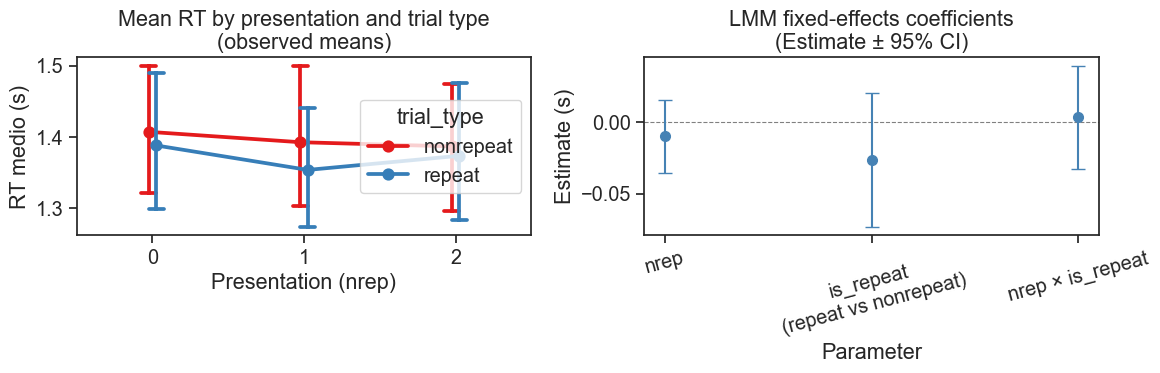


Fixed effects interpretation:
  nrep                      β=-0.0102  p=0.4343  → n.s.
  is_repeat                 β=-0.0268  p=0.2616  → n.s.
  nrep:is_repeat            β=+0.0031  p=0.8682  → n.s.


In [101]:
# ── Cell 6: Plot RT ─────────────────────────────────────────────────────────
coefs_rt_pd = coefs_rt.to_pandas()
coefs_rt_pd = coefs_rt_pd[coefs_rt_pd["term"] != "(Intercept)"].copy()

avg_rt = df_rt.groupby(["subj","nrep","trial_type"], as_index=False)["RT"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(data=avg_rt, x="nrep", y="RT", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].set_title("Mean RT by presentation and trial type\n(observed means)")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("RT medio (s)")

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_rt_pd)),
    y=coefs_rt_pd["estimate"],
    yerr=[coefs_rt_pd["estimate"] - coefs_rt_pd["conf_low"],
          coefs_rt_pd["conf_high"] - coefs_rt_pd["estimate"]],
    fmt="o", color="steelblue", capsize=5, linewidth=1.5, markersize=7
)
axes[1].set_title("LMM fixed-effects coefficients\n(Estimate ± 95% CI)")
axes[1].set_xlabel("Parameter")
axes[1].set_ylabel("Estimate (s)")
axes[1].set_xticks(range(len(coefs_rt_pd)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
plt.tight_layout()
plt.show()

print("\nFixed effects interpretation:")
for _, row in coefs_rt_pd.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [102]:
# ── Cell 7: GLMM on accuracy ────────────────────────────────────────────────
# Model: correct ~ nrep * is_repeat + (1|subj)

md_correct = glmer("correct ~ nrep * is_repeat + (1|subj)",
                   data=pl.from_pandas(df_rt),
                   family="binomial")
md_correct.fit()

coefs_correct = md_correct.result_fit
print(coefs_correct)

shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)    ┆ 0.992222  ┆ 0.06429   ┆ 0.866217  ┆ 1.118227  ┆ 15.433632 ┆ inf ┆ 9.7240e-54 │
│ nrep           ┆ 0.041651  ┆ 0.048804  ┆ -0.054003 ┆ 0.137305  ┆ 0.853429  ┆ inf ┆ 0.393421   │
│ is_repeat      ┆ -0.081489 ┆ 0.087597  ┆ -0.253176 ┆ 0.090197  ┆ -0.930276 ┆ inf ┆ 0.352228   │
│ nrep:is_repeat ┆ -0.015072 ┆ 0.068206  ┆ -0.148754 ┆ 0.11861   ┆ -0.220971 ┆ inf ┆ 0.825115   │
└────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴─────┴────────────┘


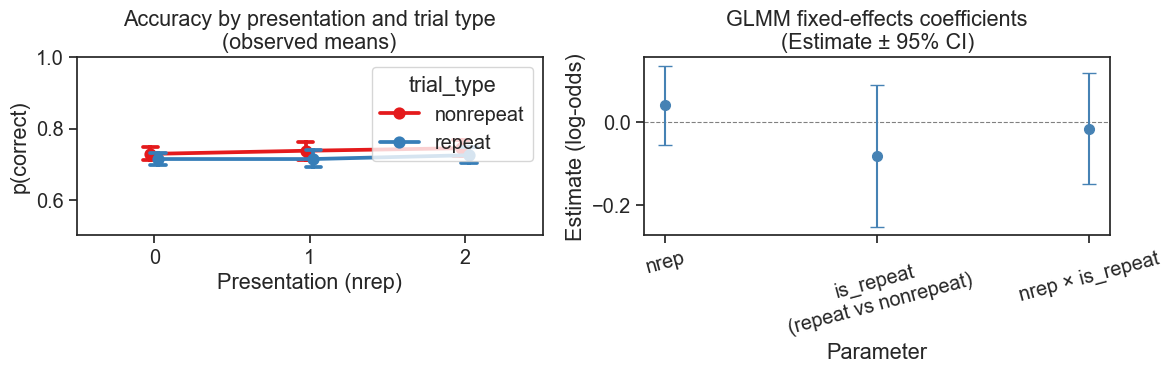


Interpretation (log-odds):
  nrep                      β=+0.0417  p=0.3934  → n.s.
  is_repeat                 β=-0.0815  p=0.3522  → n.s.
  nrep:is_repeat            β=-0.0151  p=0.8251  → n.s.


In [103]:
# ── Cell 8: Plot accuracy ──────────────────────────────────────────────────────
coefs_correct_pd = coefs_correct.to_pandas()
coefs_correct_pd = coefs_correct_pd[coefs_correct_pd["term"] != "(Intercept)"].copy()
avg_correct = df_rt.groupby(["subj","nrep","trial_type"], as_index=False)["correct"].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.pointplot(data=avg_correct, x="nrep", y="correct", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].set_title("Accuracy by presentation and trial type\n(observed means)")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p(correct)")
axes[0].set_ylim(0.5, 1.0)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_correct_pd)),
    y=coefs_correct_pd["estimate"],
    yerr=[coefs_correct_pd["estimate"] - coefs_correct_pd["conf_low"],
          coefs_correct_pd["conf_high"] - coefs_correct_pd["estimate"]],
    fmt="o", color="steelblue", capsize=5, linewidth=1.5, markersize=7
)
axes[1].set_title("GLMM fixed-effects coefficients\n(Estimate ± 95% CI)")
axes[1].set_xticks(range(len(coefs_correct_pd)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_xlabel("Parameter")
axes[1].set_ylabel("Estimate (log-odds)")
plt.tight_layout()
plt.show()
print("\nInterpretation (log-odds):")
for _, row in coefs_correct_pd.iterrows():
    sig = "✓ SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Psychometric GLMM: deci ~ rDV_z * nrep_f + (1|subj)  [nrep categorical]
shape: (6, 8)
┌───────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬─────────────┐
│ term          ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value     │
│ ---           ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---         │
│ str           ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64         │
╞═══════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪═════════════╡
│ (Intercept)   ┆ 0.404122  ┆ 0.131598  ┆ 0.146196  ┆ 0.662049  ┆ 3.070894  ┆ inf ┆ 0.002134    │
│ rDV_z         ┆ 1.326578  ┆ 0.060841  ┆ 1.207332  ┆ 1.445825  ┆ 21.803904 ┆ inf ┆ 2.1305e-105 │
│ nrep_f1       ┆ -0.046982 ┆ 0.074813  ┆ -0.193613 ┆ 0.099649  ┆ -0.627995 ┆ inf ┆ 0.530007    │
│ nrep_f2       ┆ -0.037668 ┆ 0.07535   ┆ -0.185351 ┆ 0.110015  ┆ -0.499911 ┆ inf ┆ 0.617138    │
│ rDV_z:nrep_f1 ┆ 0.06535   ┆ 0.

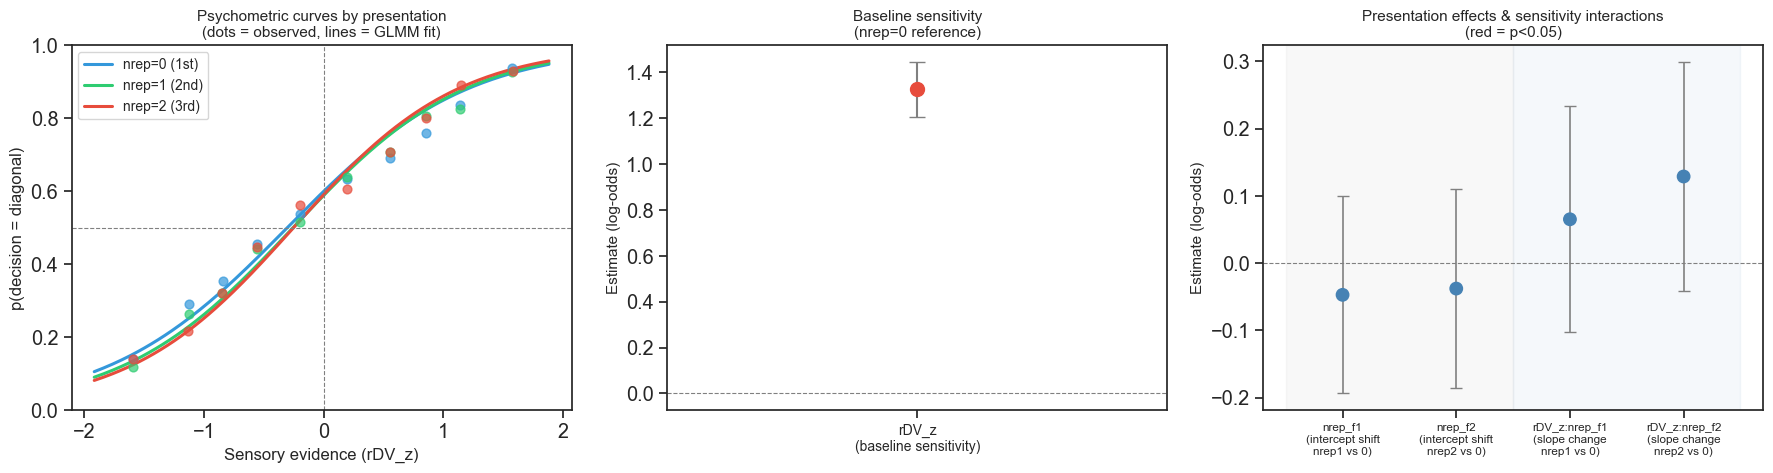


Sensitivity interactions (rDV_z slope change vs nrep=0):
  rDV_z:nrep_f1: β=+0.0654  p=0.4458  → n.s. → no significant change
  rDV_z:nrep_f2: β=+0.1290  p=0.1379  → n.s. → no significant change


In [104]:
# ── Cell 8b: Psychometric curves by presentation (nrep) ──────────────────
from scipy.special import expit  # sigmoid

# ── Bin observed data ───────────────────────────────────────────────────────
n_bins = 10
df_rt["rDV_bin"] = pd.qcut(df_rt["rDV_z"], q=n_bins, labels=False, duplicates="drop")

psy_data = df_rt.groupby(["subj", "nrep", "rDV_bin"], as_index=False).agg(
    p_deci=("deci", "mean"),
    rDV_mean=("rDV_z", "mean")
)
psy_avg = psy_data.groupby(["nrep", "rDV_bin"], as_index=False).agg(
    p_deci=("p_deci", "mean"),
    rDV_mean=("rDV_mean", "mean")
)

# ── GLMM with nrep as CATEGORICAL factor ─────────────
df_psy = df_rt.copy()
df_psy["nrep_f"] = pd.Categorical(df_psy["nrep"].astype(str),
                                    categories=["0", "1", "2"],
                                    ordered=False)

md_psy = glmer(
    "deci ~ rDV_z * nrep_f + (1|subj)",
    data=pl.from_pandas(df_psy),
    family="binomial"
)
md_psy.fit()
coefs_psy = md_psy.result_fit.to_pandas()

print("Psychometric GLMM: deci ~ rDV_z * nrep_f + (1|subj)  [nrep categorical]")
print(md_psy.result_fit)
print("\nInterpretation:")
for _, row in coefs_psy[coefs_psy["term"] != "(Intercept)"].iterrows():
    sig = "✓ SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:30s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

# ── Fitted sigmoids ──────────────────────────────────────────────────────────
def get_coef(term):
    row = coefs_psy[coefs_psy["term"] == term]
    return row["estimate"].values[0] if len(row) > 0 else 0.0

intercept_base = get_coef("(Intercept)")
slope_base     = get_coef("rDV_z")

fitted_params = {
    0: (intercept_base,                          slope_base),
    1: (intercept_base + get_coef("nrep_f1"),    slope_base + get_coef("rDV_z:nrep_f1")),
    2: (intercept_base + get_coef("nrep_f2"),    slope_base + get_coef("rDV_z:nrep_f2")),
}

x_fit = np.linspace(df_psy["rDV_z"].quantile(0.01), df_psy["rDV_z"].quantile(0.99), 200)

palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0 (1st)", 1: "nrep=1 (2nd)", 2: "nrep=2 (3rd)"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: psychometric curves ────────────────────────────────────────────
for nrep_val, color in palette_nrep.items():
    d = psy_avg[psy_avg["nrep"] == nrep_val]
    axes[0].scatter(d["rDV_mean"], d["p_deci"], color=color, s=40, alpha=0.7, zorder=3)
    intercept_k, slope_k = fitted_params[nrep_val]
    y_fit = expit(intercept_k + slope_k * x_fit)
    axes[0].plot(x_fit, y_fit, color=color, linewidth=2.2, label=labels_nrep[nrep_val])

axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].axvline(0,   color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xlabel("Sensory evidence (rDV_z)", fontsize=12)
axes[0].set_ylabel("p(decision = diagonal)", fontsize=12)
axes[0].set_title("Psychometric curves by presentation\n(dots = observed, lines = GLMM fit)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 1)

# ── Panel 2: rDV_z alone (large effect, needs its own scale) ────────────────
coef_rdvz = coefs_psy[coefs_psy["term"] == "rDV_z"].copy()
color_rdvz = ["#e74c3c" if p < 0.05 else "steelblue" for p in coef_rdvz["p_value"]]

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=[0], y=coef_rdvz["estimate"],
    yerr=[coef_rdvz["estimate"].values - coef_rdvz["conf_low"].values,
          coef_rdvz["conf_high"].values - coef_rdvz["estimate"].values],
    fmt="none", color="gray", capsize=6, linewidth=1.5, zorder=1
)
axes[1].scatter([0], coef_rdvz["estimate"], color=color_rdvz, s=100, zorder=2)
axes[1].set_xticks([0])
axes[1].set_xticklabels(["rDV_z\n(baseline sensitivity)"], fontsize=10)
axes[1].set_ylabel("Estimate (log-odds)", fontsize=11)
axes[1].set_title("Baseline sensitivity\n(nrep=0 reference)", fontsize=11)

# ── Panel 3: nrep effects + interactions (small effects, zoomed scale) ───────
terms_small = ["nrep_f1", "nrep_f2", "rDV_z:nrep_f1", "rDV_z:nrep_f2"]
coefs_small = coefs_psy[coefs_psy["term"].isin(terms_small)].copy().reset_index(drop=True)
colors_small = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_small["p_value"]]

axes[2].axvspan(-0.5, 1.5, alpha=0.05, color="gray")   
axes[2].axvspan(1.5,  3.5, alpha=0.05, color="steelblue") 

axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].errorbar(
    x=range(len(coefs_small)),
    y=coefs_small["estimate"],
    yerr=[coefs_small["estimate"] - coefs_small["conf_low"],
          coefs_small["conf_high"] - coefs_small["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[2].scatter(range(len(coefs_small)), coefs_small["estimate"],
                color=colors_small, s=80, zorder=2)
axes[2].set_xticks(range(len(coefs_small)))
axes[2].set_xticklabels(
    ["nrep_f1\n(intercept shift\nnrep1 vs 0)",
     "nrep_f2\n(intercept shift\nnrep2 vs 0)",
     "rDV_z:nrep_f1\n(slope change\nnrep1 vs 0)",
     "rDV_z:nrep_f2\n(slope change\nnrep2 vs 0)"],
    fontsize=8.5)
axes[2].set_ylabel("Estimate (log-odds)", fontsize=11)
axes[2].set_title("Presentation effects & sensitivity interactions\n(red = p<0.05)", fontsize=11)

plt.tight_layout()
plt.show()

# ── Key interpretation ───────────────────────────────────────────────────────
print("\nSensitivity interactions (rDV_z slope change vs nrep=0):")
for term in ["rDV_z:nrep_f1", "rDV_z:nrep_f2"]:
    row = coefs_psy[coefs_psy["term"] == term]
    if len(row) > 0:
        b = row["estimate"].values[0]
        p = row["p_value"].values[0]
        sig = "YES → sensitivity changes" if p < 0.05 else "n.s. → no significant change"
        print(f"  {term}: β={b:+.4f}  p={p:.4f}  → {sig}")

In [105]:
# ── Cell 9: Main GLMM — Confirmation Bias ───────────────────────────────────

# nrep as categorical factor 
# Model: deci ~ rDV_z * deci1_c * is_repeat * nrep_f + (1|subj)

df_rep = df_rt.copy()

df_rep["nrep_f"] = pd.Categorical(df_rep["nrep"].astype(str),
                                   categories=["0", "1", "2"],
                                   ordered=False)

df_rep = df_rep.dropna(subset=["rDV_z", "is_repeat"]).copy()

md_deci = glmer(
    "deci ~ rDV_z * deci1_c * is_repeat * nrep_f + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_deci.fit()

coefs_deci    = md_deci.result_fit
coefs_deci_pd = coefs_deci.to_pandas()
print(coefs_deci)

print("\nEfectos significativos (p < 0.05):")
sig = coefs_deci_pd[coefs_deci_pd["p_value"] < 0.05]
for _, row in sig.iterrows():
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}")

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA

R messages: 
Derivatives (gradient and/or Hessian) not available. Cannot assess
  convergence through gradient-based checks.

Convergence status
: [1] FALSE
attr(,"gradient")
[1] NA

shape: (24, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ 0.396363  ┆ 0.121119  ┆ 0.158974  ┆ 0.633753  ┆ 3.272506  ┆ inf ┆ 0.001066   │
│ rDV_z      

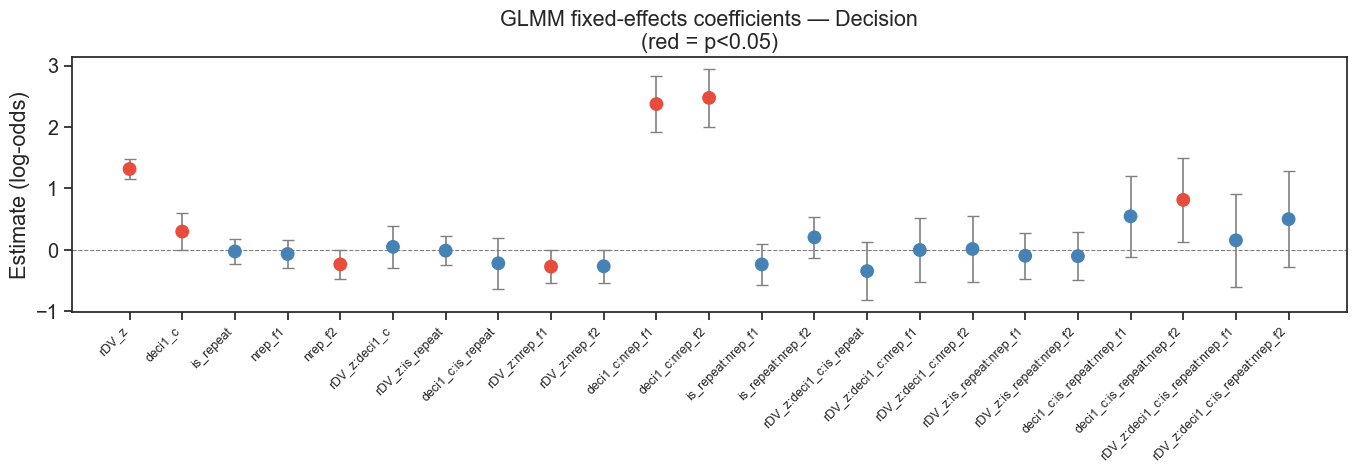

In [106]:
# ── Cell 10: Plot main model ────────────────────────────────────────────────
coefs_plot = coefs_deci_pd[coefs_deci_pd["term"] != "(Intercept)"].copy()
colors = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_value"]]

fig, ax = plt.subplots(figsize=(14, 5))
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["estimate"],
    yerr=[coefs_plot["estimate"] - coefs_plot["conf_low"],
          coefs_plot["conf_high"] - coefs_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
ax.scatter(range(len(coefs_plot)), coefs_plot["estimate"],
           color=colors, s=80, zorder=2)
ax.set_xticks(range(len(coefs_plot)))
ax.set_xticklabels(coefs_plot["term"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Estimate (log-odds)")
ax.set_title("GLMM fixed-effects coefficients — Decision\n(red = p<0.05)")
plt.tight_layout()
plt.show()

In [107]:
# ── Cell 11: GLMM Switch ────────────────────────────────────────────────────
# Model: switch ~ nrep * is_repeat + (1|subj)

md_switch = glmer(
    "switch ~ nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_switch.fit()

coefs_switch    = md_switch.result_fit
coefs_switch_pd = coefs_switch.to_pandas()
print(coefs_switch)

intercept   = coefs_switch_pd.loc[coefs_switch_pd["term"]=="(Intercept)", "estimate"].values[0]
p_switch    = 1 / (1 + np.exp(-intercept))
print(f"\nBaseline p(switch decision): {p_switch:.3f}")
print(f"Baseline p(repeat decision): {1-p_switch:.3f}")

shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)    ┆ -0.372088 ┆ 0.078511  ┆ -0.525967 ┆ -0.218208 ┆ -4.739292 ┆ inf ┆ 0.000002   │
│ nrep           ┆ -0.857399 ┆ 0.055437  ┆ -0.966054 ┆ -0.748743 ┆ -15.46608 ┆ inf ┆ 5.8779e-54 │
│ is_repeat      ┆ 0.075086  ┆ 0.082938  ┆ -0.087469 ┆ 0.237642  ┆ 0.905334  ┆ inf ┆ 0.365289   │
│ nrep:is_repeat ┆ -0.178995 ┆ 0.080628  ┆ -0.337023 ┆ -0.020967 ┆ -2.220008 ┆ inf ┆ 0.026418   │
└────────────────┴───────────┴───────────┴───────────┴───────────┴───────────┴─────┴────────────┘

Basel

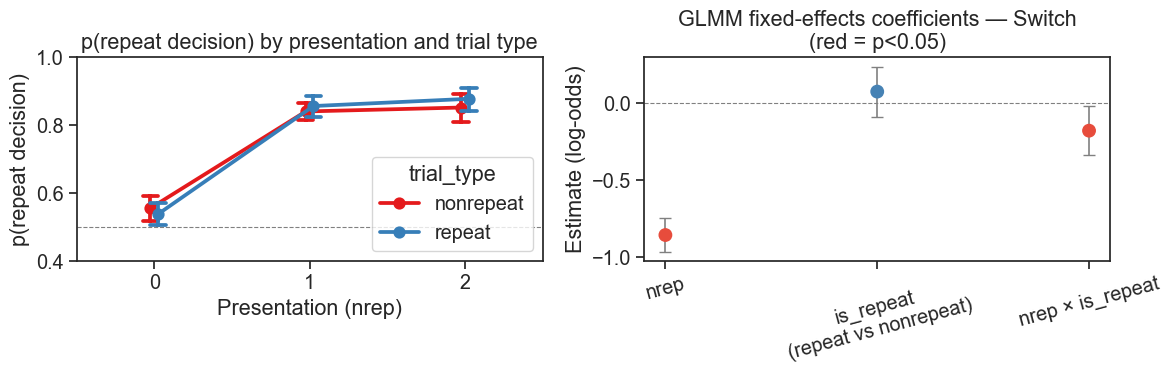


Interpretation:
  nrep                      β=-0.8574  p=0.0000  → ✓ SIGNIFICATIVO
  is_repeat                 β=+0.0751  p=0.3653  → n.s.
  nrep:is_repeat            β=-0.1790  p=0.0264  → ✓ SIGNIFICATIVO


In [108]:
# ── Cell 12: Plot Switch ────────────────────────────────────────────────────
avg_switch = df_rep.groupby(["subj","nrep","trial_type"], as_index=False)["switch"].mean()
avg_switch["p_repeat"] = 1 - avg_switch["switch"]

coefs_sw_plot = coefs_switch_pd[coefs_switch_pd["term"] != "(Intercept)"].copy()
colors_sw     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_sw_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.pointplot(data=avg_switch, x="nrep", y="p_repeat", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repeat decision) by presentation and trial type")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p(repeat decision)")
axes[0].set_ylim(0.4, 1.0)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_sw_plot)),
    y=coefs_sw_plot["estimate"],
    yerr=[coefs_sw_plot["estimate"] - coefs_sw_plot["conf_low"],
          coefs_sw_plot["conf_high"] - coefs_sw_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_sw_plot)), coefs_sw_plot["estimate"],
                color=colors_sw, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_sw_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients — Switch\n(red = p<0.05)")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
for _, row in coefs_sw_plot.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [109]:
# ── Cell 11b: GLMM Switch + sensory evidence ────────────────────────────────
# Model: switch ~ rDV_z * nrep * is_repeat + (1|subj)

md_switch = glmer(
    "switch ~ rDV_z * nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_rep),
    family="binomial"
)
md_switch.fit()

coefs_switch    = md_switch.result_fit
coefs_switch_pd = coefs_switch.to_pandas()
print(coefs_switch)

intercept = coefs_switch_pd.loc[coefs_switch_pd["term"] == "(Intercept)", "estimate"].values[0]
p_switch  = 1 / (1 + np.exp(-intercept))
print(f"\nBaseline p(switch decision): {p_switch:.3f}")
print(f"Baseline p(repeat decision): {1 - p_switch:.3f}")

print("\nEfectos significativos (p < 0.05):")
sig_sw = coefs_switch_pd[coefs_switch_pd["p_value"] < 0.05]
for _, row in sig_sw.iterrows():
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}")

shape: (8, 8)
┌──────────────────┬───────────┬───────────┬───────────┬───────────┬────────────┬─────┬────────────┐
│ term             ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat     ┆ df  ┆ p_value    │
│ ---              ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ --- ┆ ---        │
│ str              ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64 ┆ f64        │
╞══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╪═════╪════════════╡
│ (Intercept)      ┆ -0.375073 ┆ 0.078794  ┆ -0.529507 ┆ -0.220639 ┆ -4.760143  ┆ inf ┆ 0.000002   │
│ rDV_z            ┆ -0.11963  ┆ 0.059145  ┆ -0.235552 ┆ -0.003708 ┆ -2.022657  ┆ inf ┆ 0.043109   │
│ nrep             ┆ -0.861386 ┆ 0.05576   ┆ -0.970674 ┆ -0.752099 ┆ -15.448097 ┆ inf ┆ 7.7704e-54 │
│ is_repeat        ┆ 0.078793  ┆ 0.08306   ┆ -0.084001 ┆ 0.241588  ┆ 0.94863    ┆ inf ┆ 0.342809   │
│ rDV_z:nrep       ┆ -0.015633 ┆ 0.05582   ┆ -0.125038 ┆ 0.093771  ┆ -0.28006

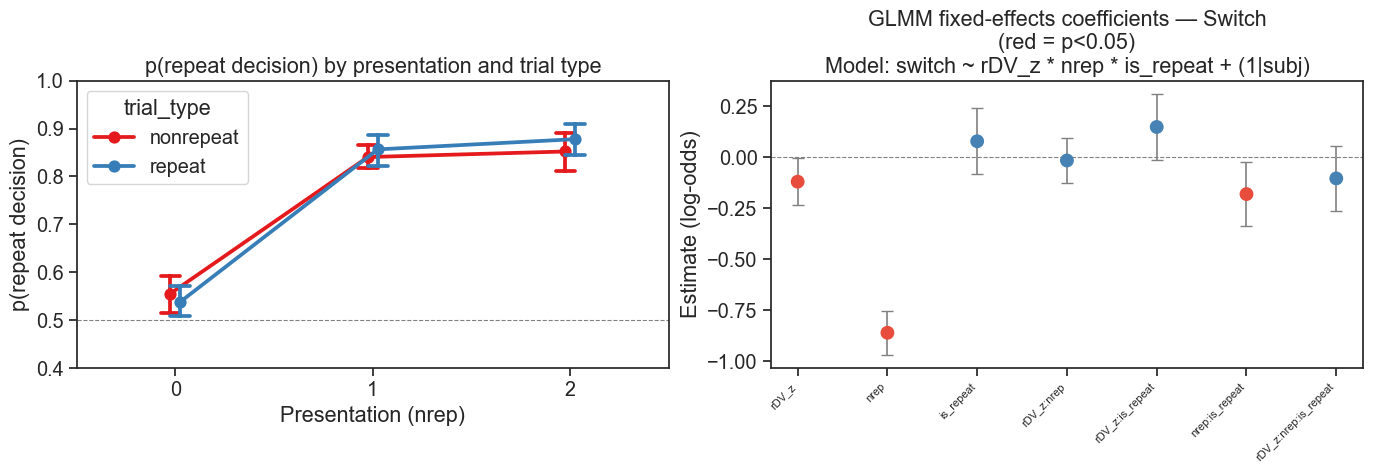


Interpretation:
  rDV_z                               β=-0.1196  p=0.0431  → ✓ SIGNIFICANT
  nrep                                β=-0.8614  p=0.0000  → ✓ SIGNIFICANT
  is_repeat                           β=+0.0788  p=0.3428  → n.s.
  rDV_z:nrep                          β=-0.0156  p=0.7794  → n.s.
  rDV_z:is_repeat                     β=+0.1488  p=0.0741  → n.s.
  nrep:is_repeat                      β=-0.1806  p=0.0259  → ✓ SIGNIFICANT
  rDV_z:nrep:is_repeat                β=-0.1035  p=0.2017  → n.s.


In [110]:
# ── Cell 12: Plot Switch ─────────────────────────────────────────────────────
avg_switch = df_rep.groupby(["subj", "nrep", "trial_type"], as_index=False)["switch"].mean()
avg_switch["p_repeat"] = 1 - avg_switch["switch"]

coefs_sw_plot = coefs_switch_pd[coefs_switch_pd["term"] != "(Intercept)"].copy().reset_index(drop=True)
colors_sw     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_sw_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.pointplot(data=avg_switch, x="nrep", y="p_repeat", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repeat decision) by presentation and trial type")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p(repeat decision)")
axes[0].set_ylim(0.4, 1.0)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_sw_plot)),
    y=coefs_sw_plot["estimate"],
    yerr=[coefs_sw_plot["estimate"] - coefs_sw_plot["conf_low"],
          coefs_sw_plot["conf_high"] - coefs_sw_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_sw_plot)), coefs_sw_plot["estimate"],
                color=colors_sw, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_sw_plot)))
axes[1].set_xticklabels(coefs_sw_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients — Switch\n(red = p<0.05)\nModel: switch ~ rDV_z * nrep * is_repeat + (1|subj)")

plt.tight_layout()
plt.show()

print("\nInterpretation:")
for _, row in coefs_sw_plot.iterrows():
    sig = "✓ SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [111]:
# ── Cell 13: GLMM Confidence → Switch ──────────────────────────────────────
# Model: switch ~ confi1_z * nrep * is_repeat + (1|subj)

df_confi = df_rt[df_rt["nrep"] > 0].copy()
df_confi = df_confi.dropna(subset=["confi-1"]).reset_index(drop=True)
df_confi["confi1_z"] = df_confi.groupby("subj")["confi-1"].transform(
    lambda x: (x - x.mean()) / x.std())

print(f"Trials: {len(df_confi)} | Participants: {df_confi['subj'].nunique()}")

md_confi = glmer(
    "switch ~ confi1_z * nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_confi),
    family="binomial"
)
md_confi.fit()

coefs_confi    = md_confi.result_fit
coefs_confi_pd = coefs_confi.to_pandas()
print(coefs_confi)

print("\nInterpretation:")
for _, row in coefs_confi_pd[coefs_confi_pd["term"] != "(Intercept)"].iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:30s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 4370 | Participants: 25
shape: (8, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ -2.213715 ┆ 0.256092  ┆ -2.715646 ┆ -1.711784 ┆ -8.644216 ┆ inf ┆ 5.4176e-18 │
│ confi1_z          ┆ -0.977478 ┆ 0.211207  ┆ -1.391436 ┆ -0.56352  ┆ -4.628055 ┆ inf ┆ 0.000004   │
│ nrep              ┆ 0.145381  ┆ 0.138572  ┆ -0.126216 ┆ 0.416978  ┆ 1.049134  ┆ inf ┆ 0.294117   │
│ is_repeat         ┆ 0.191185  ┆ 0.327877  ┆ -0.451443 ┆ 0.833812  ┆ 0.583099  ┆ inf ┆ 0.559827   │
│ confi1_z:nrep     ┆ 0.182223  ┆ 0.134097  ┆

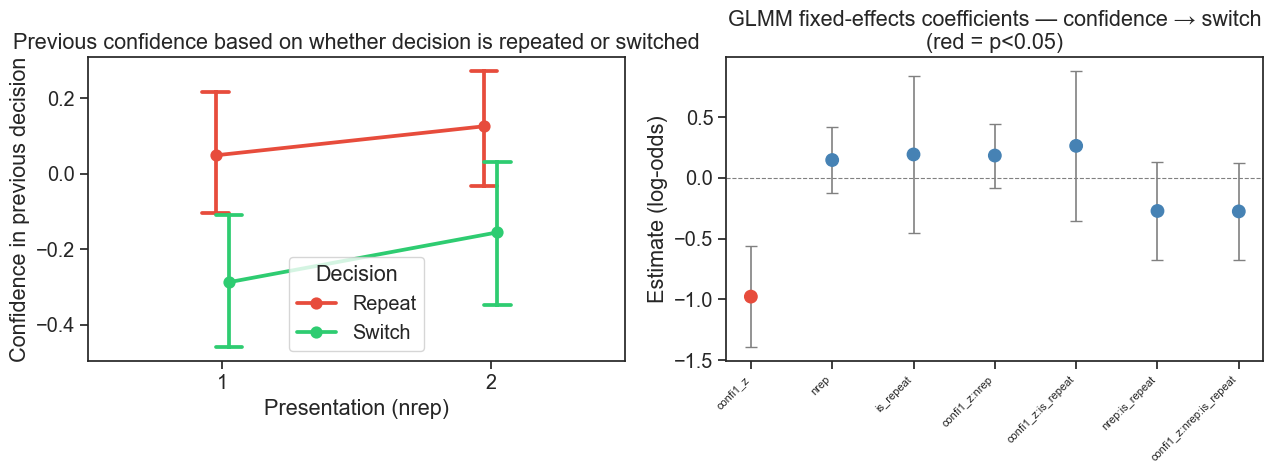

In [112]:
# ── Cell 14: Plot Confidence → Switch ────────────────────────────────────────
avg_confi_switch = df_confi.groupby(
    ["subj", "nrep", "switch"], as_index=False
)["confi-1"].mean()
coefs_cf_plot = coefs_confi_pd[coefs_confi_pd["term"] != "(Intercept)"].copy()
colors_cf     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_cf_plot["p_value"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.pointplot(data=avg_confi_switch, x="nrep", y="confi-1", hue="switch",
              dodge=True, capsize=0.1,
              palette={0: "#e74c3c", 1: "#2ecc71"}, ax=axes[0])
axes[0].set_title("Previous confidence based on whether decision is repeated or switched")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("Confidence in previous decision")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, ["Repeat", "Switch"], title="Decision")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_cf_plot)),
    y=coefs_cf_plot["estimate"],
    yerr=[coefs_cf_plot["estimate"] - coefs_cf_plot["conf_low"],
          coefs_cf_plot["conf_high"] - coefs_cf_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_cf_plot)), coefs_cf_plot["estimate"],
                color=colors_cf, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_cf_plot)))
axes[1].set_xticklabels(coefs_cf_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients — confidence → switch\n(red = p<0.05)")
plt.tight_layout()
plt.show()

In [113]:
# ── Cell 15: Stimulus weights ───────────────────────────────────────────────
# Model: deci ~ deci1_c + d1_z + ... + d6_z + (1|subj) per nrep

for col in ["d1","d2","d3","d4","d5","d6"]:
    df_rep[f"{col}_z"] = df_rep.groupby("subj")[col].transform(
        lambda x: (x - x.mean()) / x.std())

results_stim = []

for nrep_val in [1, 2]:
    dat = df_rep[df_rep["nrep"] == nrep_val].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        md = glmer(
            "deci ~ deci1_c + d1_z + d2_z + d3_z + d4_z + d5_z + d6_z + (1|subj)",
            data=pl.from_pandas(dat),
            family="binomial"
        )
        md.fit()

    res = md.result_fit.to_pandas()
    res["nrep"] = nrep_val
    results_stim.append(res)

df_coefs_stim = pd.concat(results_stim, ignore_index=True)
print(df_coefs_stim[["nrep","term","estimate","p_value"]].round(4))

    nrep         term  estimate  p_value
0      1  (Intercept)    0.1967   0.0868
1      1      deci1_c    2.9692   0.0000
2      1         d1_z    0.4379   0.0000
3      1         d2_z    0.3126   0.0000
4      1         d3_z    0.3786   0.0000
5      1         d4_z    0.3721   0.0000
6      1         d5_z    0.4181   0.0000
7      1         d6_z    0.3151   0.0000
8      2  (Intercept)    0.2433   0.0391
9      2      deci1_c    3.1250   0.0000
10     2         d1_z    0.2830   0.0000
11     2         d2_z    0.4229   0.0000
12     2         d3_z    0.4113   0.0000
13     2         d4_z    0.3485   0.0000
14     2         d5_z    0.3488   0.0000
15     2         d6_z    0.4340   0.0000


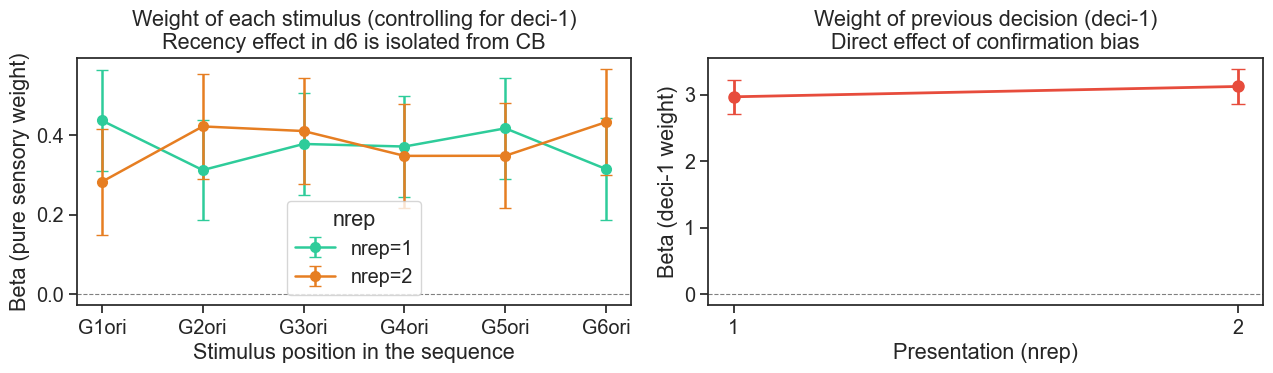

Test deci-1 weight:
  nrep=1: β=+2.9692  p=0.0000  → ✓ SIGNIFICANT
  nrep=2: β=+3.1250  p=0.0000  → ✓ SIGNIFICANT


In [114]:
# ── Cell 16: Plot stimulus weights ───────────────────────────────────────────
stim_names = ["d1_z","d2_z","d3_z","d4_z","d5_z","d6_z"]
df_stim = df_coefs_stim[df_coefs_stim["term"].isin(stim_names)].copy()
df_deci = df_coefs_stim[df_coefs_stim["term"] == "deci1_c"].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {1: "#2ecc9a", 2: "#e67e22"}
for nrep_val, color in palette.items():
    d = df_stim[df_stim["nrep"] == nrep_val]
    axes[0].errorbar(
        x=range(6), y=d["estimate"],
        yerr=[d["estimate"] - d["conf_low"], d["conf_high"] - d["estimate"]],
        fmt="o-", color=color, capsize=4, label=f"nrep={nrep_val}",
        linewidth=1.8, markersize=7
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["G1ori","G2ori","G3ori","G4ori","G5ori","G6ori"])
axes[0].set_xlabel("Stimulus position in the sequence")
axes[0].set_ylabel("Beta (pure sensory weight)")
axes[0].set_title("Weight of each stimulus (controlling for deci-1)\nRecency effect in d6 is isolated from CB")
axes[0].legend(title="nrep")
axes[1].errorbar(
    x=[0, 1], y=df_deci["estimate"],
    yerr=[df_deci["estimate"] - df_deci["conf_low"],
          df_deci["conf_high"] - df_deci["estimate"]],
    fmt="o-", color="#e74c3c", capsize=5, linewidth=2, markersize=8
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["1", "2"])
axes[1].set_xlabel("Presentation (nrep)")
axes[1].set_ylabel("Beta (deci-1 weight)")
axes[1].set_title("Weight of previous decision (deci-1)\nDirect effect of confirmation bias")
plt.tight_layout()                                                                              
plt.show()
print("Test deci-1 weight:")
for _, row in df_deci.iterrows():
    sig = "✓ SIGNIFICANT" if row["p_value"] < 0.05 else "n.s."
    print(f"  nrep={row['nrep']}: β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [115]:
# ── Cell 17: CB Index ───────────────────────────────────────────────────────
# G1sim = most congruent with prev decision, G6sim = most incongruent
# CB_idx = posw(G1,G2) - negw(G5,G6)

prev_deci     = df_rep["deci-1"].copy().replace({0: -1})
orientations  = df_rep[["d1","d2","d3","d4","d5","d6"]].values
prev_respdiff = orientations * prev_deci.values[:, None]
sort_idx      = prev_respdiff.argsort(axis=1)[:, ::-1]
reo_orien     = np.take_along_axis(orientations, sort_idx, axis=1)

reo_df = pd.DataFrame(reo_orien, columns=["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"])
df_glm = pd.concat([df_rep.reset_index(drop=True), reo_df], axis=1)
df_glm["deci_prev"] = prev_deci.values

for col in ["G1sim","G2sim","G3sim","G4sim","G5sim","G6sim"]:
    df_glm[f"{col}_z"] = df_glm.groupby("subj")[col].transform(
        lambda x: (x - x.mean()) / x.std())

sim_names    = ["G1sim_z","G2sim_z","G3sim_z","G4sim_z","G5sim_z","G6sim_z"]
results_sim  = []

for nrep_val in [1, 2]:
    dat = df_glm[df_glm["nrep"] == nrep_val].copy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        md = glmer(
            "deci ~ deci_prev + G1sim_z + G2sim_z + G3sim_z + G4sim_z + G5sim_z + G6sim_z + (1|subj)",
            data=pl.from_pandas(dat),
            family="binomial"
        )
        md.fit()

    res = md.result_fit.to_pandas()
    res["nrep"] = nrep_val
    results_sim.append(res)

df_coefs_sim = pd.concat(results_sim, ignore_index=True)

print("CB index by nrep:")
for nrep_val in [1, 2]:
    d    = df_coefs_sim[df_coefs_sim["nrep"] == nrep_val]
    posw = d[d["term"].isin(["G1sim_z","G2sim_z"])]["estimate"].mean()
    negw = d[d["term"].isin(["G5sim_z","G6sim_z"])]["estimate"].mean()
    cb   = posw - negw
    print(f"  nrep={nrep_val}: posw={posw:.4f}, negw={negw:.4f}, CB_idx={cb:.4f}")

CB index by nrep:
  nrep=1: posw=-0.0567, negw=0.2773, CB_idx=-0.3340
  nrep=2: posw=-0.0356, negw=0.4920, CB_idx=-0.5277


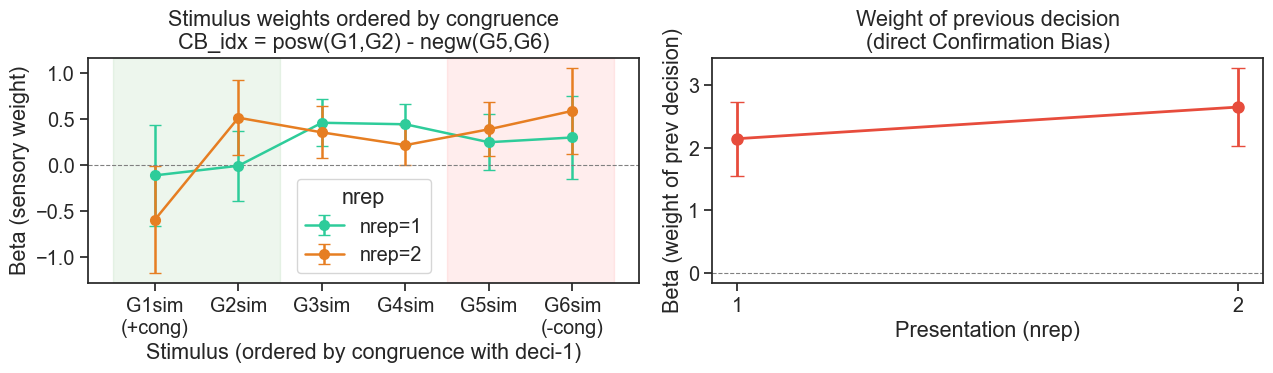

In [116]:
# ── Cell 18: Plot CB Index ──────────────────────────────────────────────────
df_sim = df_coefs_sim[df_coefs_sim["term"].isin(sim_names)].copy()
df_dp  = df_coefs_sim[df_coefs_sim["term"] == "deci_prev"].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

palette = {1: "#2ecc9a", 2: "#e67e22"}
for nrep_val, color in palette.items():
    d = df_sim[df_sim["nrep"] == nrep_val]
    axes[0].errorbar(
        x=range(6), y=d["estimate"],
        yerr=[d["estimate"] - d["conf_low"], d["conf_high"] - d["estimate"]],
        fmt="o-", color=color, capsize=4, label=f"nrep={nrep_val}",
        linewidth=1.8, markersize=7
    )
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(["G1sim\n(+cong)","G2sim","G3sim","G4sim","G5sim","G6sim\n(-cong)"])
axes[0].set_xlabel("Stimulus (ordered by congruence with deci-1)")
axes[0].set_ylabel("Beta (sensory weight)")
axes[0].set_title("Stimulus weights ordered by congruence\nCB_idx = posw(G1,G2) - negw(G5,G6)")
axes[0].legend(title="nrep")
axes[0].axvspan(-0.5, 1.5, alpha=0.07, color="green")
axes[0].axvspan(3.5, 5.5, alpha=0.07, color="red")

axes[1].errorbar(
    x=[0, 1], y=df_dp["estimate"],
    yerr=[df_dp["estimate"] - df_dp["conf_low"],
          df_dp["conf_high"] - df_dp["estimate"]],
    fmt="o-", color="#e74c3c", capsize=5, linewidth=2, markersize=8
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["1", "2"])
axes[1].set_xlabel("Presentation (nrep)")
axes[1].set_ylabel("Beta (weight of prev decision)")
axes[1].set_title("Weight of previous decision\n(direct Confirmation Bias)")
plt.tight_layout()
plt.show()

In [117]:
# ── Cell 19: GLMM Stubbornness ──────────────────────────────────────────────
# Trials where correct-1 == 0 (previous error only)
# Model: switch ~ nrep * is_repeat + (1|subj)

df_err = df_rep[df_rep["correct-1"] == 0].copy()

print(f"Trials with previous error : {len(df_err)}")
print(f"Global mean stubbornness   : {(1 - df_err['switch'].mean()):.3f}")
print()
print("Stubbornness by condition (p(no switch | previous error)):")
print(df_err.groupby(["nrep","trial_type"])["switch"].apply(
    lambda x: (1 - x.mean())).round(3))

md_stub = glmer(
    "switch ~ nrep * is_repeat + (1|subj)",
    data=pl.from_pandas(df_err),
    family="binomial"
)
md_stub.fit()

coefs_stub    = md_stub.result_fit
coefs_stub_pd = coefs_stub.to_pandas()
print(coefs_stub)

intercept_stub = coefs_stub_pd.loc[coefs_stub_pd["term"]=="(Intercept)", "estimate"].values[0]
p_stub = 1 / (1 + np.exp(-intercept_stub))
print(f"\np(NO switch | previous error): {1-p_stub:.3f}")
print(f"→ Participants maintain their incorrect decision {(1-p_stub)*100:.1f}% of the time")

Trials with previous error : 1786
Global mean stubbornness   : 0.675

Stubbornness by condition (p(no switch | previous error)):
nrep  trial_type
0     nonrepeat     0.545
      repeat        0.589
1     nonrepeat     0.687
      repeat        0.746
2     nonrepeat     0.704
      repeat        0.771
Name: switch, dtype: float64
shape: (4, 8)
┌────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬──────────┐
│ term           ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value  │
│ ---            ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---      │
│ str            ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64      │
╞════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪══════════╡
│ (Intercept)    ┆ -0.252508 ┆ 0.122579  ┆ -0.492758 ┆ -0.012258 ┆ -2.059966 ┆ inf ┆ 0.039402 │
│ nrep           ┆ -0.361483 ┆ 0.088658  ┆ -0.535248 ┆ -0.187717 ┆ -4.077288 ┆ 

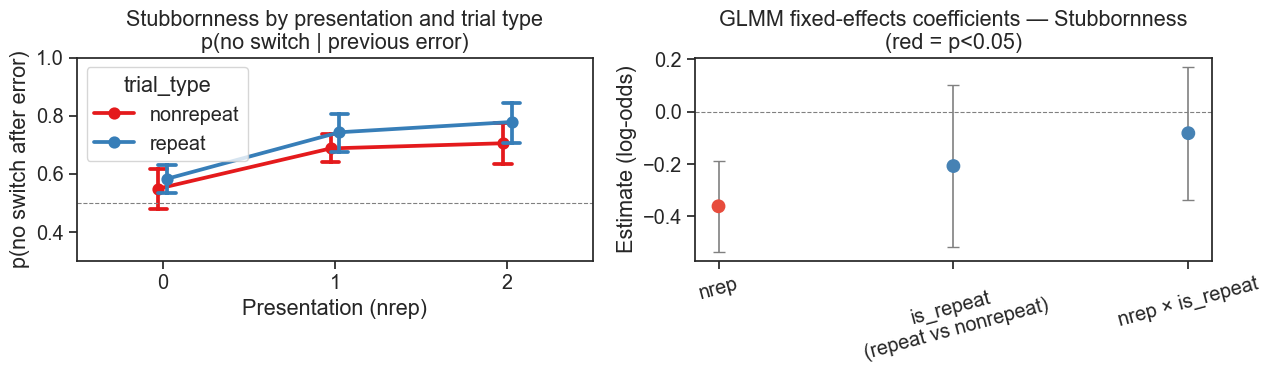


Interpretation:
  nrep                      β=-0.3615  p=0.0000  → ✓ SIGNIFICATIVO
  is_repeat                 β=-0.2077  p=0.1883  → n.s.
  nrep:is_repeat            β=-0.0822  p=0.5254  → n.s.


In [118]:
# ── Cell 20: Plot Stubbornness ──────────────────────────────────────────────
avg_stub = df_err.groupby(["subj","nrep","trial_type"], as_index=False)["switch"].mean()
avg_stub["stubbornness"] = 1 - avg_stub["switch"]

coefs_st_plot = coefs_stub_pd[coefs_stub_pd["term"] != "(Intercept)"].copy()
colors_st     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_st_plot["p_value"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.pointplot(data=avg_stub, x="nrep", y="stubbornness", hue="trial_type",
              dodge=True, capsize=0.1, palette="Set1", ax=axes[0])
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="azar")
axes[0].set_title("Stubbornness by presentation and trial type\np(no switch | previous error)")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p(no switch after error)")
axes[0].set_ylim(0.3, 1.0)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_st_plot)),
    y=coefs_st_plot["estimate"],
    yerr=[coefs_st_plot["estimate"] - coefs_st_plot["conf_low"],
          coefs_st_plot["conf_high"] - coefs_st_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_st_plot)), coefs_st_plot["estimate"],
                color=colors_st, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_st_plot)))
axes[1].set_xticklabels(
    ["nrep", "is_repeat\n(repeat vs nonrepeat)", "nrep × is_repeat"],
    rotation=15)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients — Stubbornness\n(red = p<0.05)")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
for _, row in coefs_st_plot.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:25s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

In [119]:
# ── Cell 21: GLMM Global Metacognition ──────────────────────────────────────
# Model: correct ~ nrep * metad_eff + correct_prev + (1|subj)

df0 = df_rt[df_rt["nrep"] == 0].copy()

def calc_dprime(x):
    hits   = ((x["deci"] == 1) & (x["cond"] == 1)).sum()
    signal = (x["cond"] == 1).sum()
    fa     = ((x["deci"] == 1) & (x["cond"] == 0)).sum()
    noise  = (x["cond"] == 0).sum()
    hr  = (hits + 0.5) / (signal + 1)
    far = (fa   + 0.5) / (noise  + 1)
    return pd.Series({"dprime": norm.ppf(hr) - norm.ppf(far)})

dprime_df  = df0.groupby("subj").apply(calc_dprime, include_groups=False).reset_index()
metad_subj = df_rt.groupby("subj")["metad"].first().reset_index()
eff_df     = metad_subj.merge(dprime_df, on="subj")
eff_df["metad_eff"] = eff_df["metad"] / eff_df["dprime"]

df_meta = df_rt[df_rt["nrep"] > 0].copy()
df_meta = df_meta.rename(columns={"correct-1": "correct_prev"})
df_meta["correct_prev"] = df_meta["correct_prev"].astype(float)
df_meta = df_meta.merge(eff_df[["subj", "metad_eff"]], on="subj")
df_meta["metad_eff_z"] = (df_meta["metad_eff"] - df_meta["metad_eff"].mean()) / df_meta["metad_eff"].std()
df_meta = df_meta.dropna(subset=["correct", "correct_prev", "metad_eff_z"]).reset_index(drop=True)

print(f"Trials: {len(df_meta)} | Participants: {df_meta['subj'].nunique()}")

md_metad = glmer(
    "correct ~ nrep * metad_eff_z + correct_prev + (1|subj)",
    data=pl.from_pandas(df_meta),
    family="binomial"
)
md_metad.fit()

coefs_metad    = md_metad.result_fit
coefs_metad_pd = coefs_metad.to_pandas()
print(coefs_metad)

print("\nInterpretation:")
for _, row in coefs_metad_pd.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:30s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 4195 | Participants: 24
shape: (5, 8)
┌──────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬─────────────┐
│ term             ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value     │
│ ---              ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---         │
│ str              ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64         │
╞══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪═════════════╡
│ (Intercept)      ┆ -0.994264 ┆ 0.152329  ┆ -1.292822 ┆ -0.695705 ┆ -6.527099 ┆ inf ┆ 6.7056e-11  │
│ nrep             ┆ 0.007811  ┆ 0.090589  ┆ -0.169739 ┆ 0.185362  ┆ 0.086229  ┆ inf ┆ 0.931285    │
│ metad_eff_z      ┆ 0.233873  ┆ 0.145479  ┆ -0.05126  ┆ 0.519007  ┆ 1.607608  ┆ inf ┆ 0.107921    │
│ correct_prev     ┆ 3.252261  ┆ 0.091093  ┆ 3.073722  ┆ 3.430801  ┆ 35.702541 ┆ inf ┆ 3.6101e-279 │
│ nrep:metad_eff_z ┆ -0.126744 ┆ 0.090617  ┆ 

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_95728/801670330.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_meta_global = df_meta.groupby(


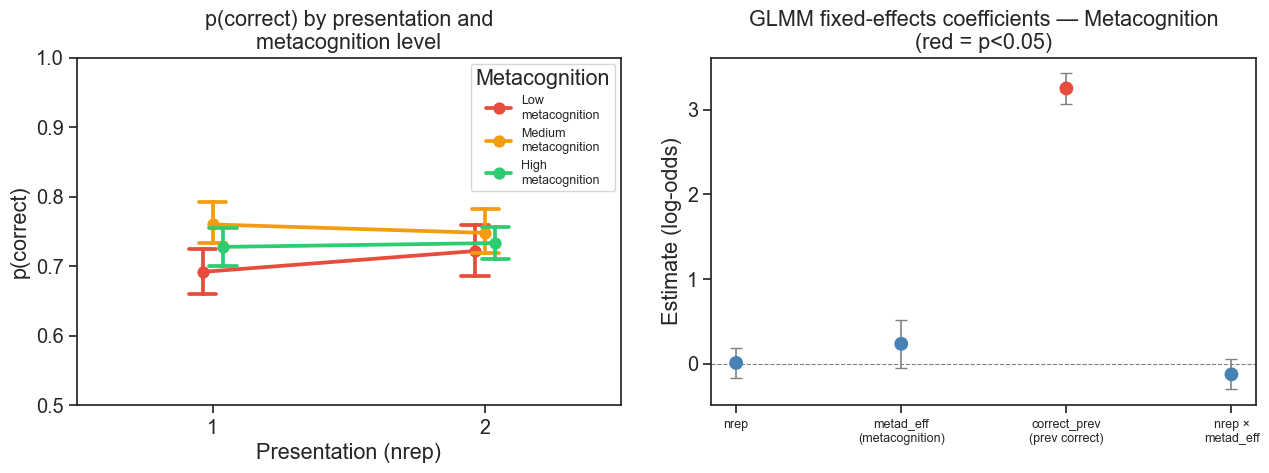

In [120]:
# ── Cell 21b: Plot Global Metacognition ─────────────────────────────────────

df_meta["metad_eff_bin"] = pd.qcut(
    df_meta["metad_eff_z"], q=3,
    labels=["Low\nmetacognition", "Medium\nmetacognition", "High\nmetacognition"]
)

avg_meta_global = df_meta.groupby(
    ["subj", "nrep", "metad_eff_bin"], as_index=False
)["correct"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.pointplot(
    data=avg_meta_global, x="nrep", y="correct",
    hue="metad_eff_bin", dodge=True, capsize=0.1,
    palette={"Low\nmetacognition": "#e74c3c",
             "Medium\nmetacognition": "#f39c12",
             "High\nmetacognition": "#2ecc71"},
    ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(correct) by presentation and\nmetacognition level")
axes[0].set_xlabel("Presentation (nrep)")
axes[0].set_ylabel("p(correct)")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title="Metacognition", fontsize=9)

coefs_plot = coefs_metad_pd[coefs_metad_pd["term"] != "(Intercept)"].copy()
colors_m   = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_plot["p_value"]]

axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_plot)),
    y=coefs_plot["estimate"],
    yerr=[coefs_plot["estimate"] - coefs_plot["conf_low"],
          coefs_plot["conf_high"] - coefs_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_plot)), coefs_plot["estimate"],
                color=colors_m, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_plot)))
axes[1].set_xticklabels(
    ["nrep", "metad_eff\n(metacognition)", "correct_prev\n(prev correct)", "nrep ×\nmetad_eff"],
    fontsize=9)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM fixed-effects coefficients — Metacognition\n(red = p<0.05)")

plt.tight_layout()
plt.show()

In [121]:
# ── Cell 22: GLMM Trial-by-trial Metacognition ──────────────────────────────
# Model: deci ~ rDV_z + deci1_c * confi1_z * correct_prev + (1|subj)

df_rep_meta = df_rt[df_rt["nrep"] > 0].dropna(
    subset=["deci1_c", "rDV_z", "is_repeat"]
).copy()

df_rep_meta["confi-1"] = df_rep_meta.groupby(
    ["subj", "nblock", "ntrial"]
)["confi"].shift(1)

df_meta_trial = df_rep_meta.dropna(subset=["confi-1"]).copy()
df_meta_trial["confi1_z"] = df_meta_trial.groupby("subj")["confi-1"].transform(
    lambda x: (x - x.mean()) / x.std())
df_meta_trial["correct_prev"] = df_meta_trial["correct-1"].astype(float)

print(f"Trials: {len(df_meta_trial)} | Participants: {df_meta_trial['subj'].nunique()}")

md_meta_trial = glmer(
    "deci ~ rDV_z + deci1_c * confi1_z * correct_prev + (1|subj)",
    data=pl.from_pandas(df_meta_trial),
    family="binomial"
)
md_meta_trial.fit()

coefs_mt    = md_meta_trial.result_fit
coefs_mt_pd = coefs_mt.to_pandas()
print(coefs_mt)

print("\nEfectos significativos:")
for _, row in coefs_mt_pd.iterrows():
    sig = "✓ SIGNIFICATIVO" if row["p_value"] < 0.05 else "n.s."
    print(f"  {row['term']:35s} β={row['estimate']:+.4f}  p={row['p_value']:.4f}  → {sig}")

Trials: 2170 | Participants: 25
shape: (9, 8)
┌───────────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬─────┬────────────┐
│ term              ┆ estimate  ┆ std_error ┆ conf_low  ┆ conf_high ┆ z_stat    ┆ df  ┆ p_value    │
│ ---               ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ --- ┆ ---        │
│ str               ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64 ┆ f64        │
╞═══════════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪═════╪════════════╡
│ (Intercept)       ┆ 0.186456  ┆ 0.146431  ┆ -0.100543 ┆ 0.473456  ┆ 1.273341  ┆ inf ┆ 0.202897   │
│ rDV_z             ┆ 0.920719  ┆ 0.150526  ┆ 0.625694  ┆ 1.215744  ┆ 6.116686  ┆ inf ┆ 9.5541e-10 │
│ deci1_c           ┆ 3.48546   ┆ 0.313407  ┆ 2.871193  ┆ 4.099726  ┆ 11.12119  ┆ inf ┆ 9.8943e-29 │
│ confi1_z          ┆ 0.030666  ┆ 0.117136  ┆ -0.198917 ┆ 0.260249  ┆ 0.261798  ┆ inf ┆ 0.793477   │
│ correct_prev      ┆ 0.124841  ┆ 0.156244  ┆

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_95728/216808587.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_meta = df_meta_trial.groupby(


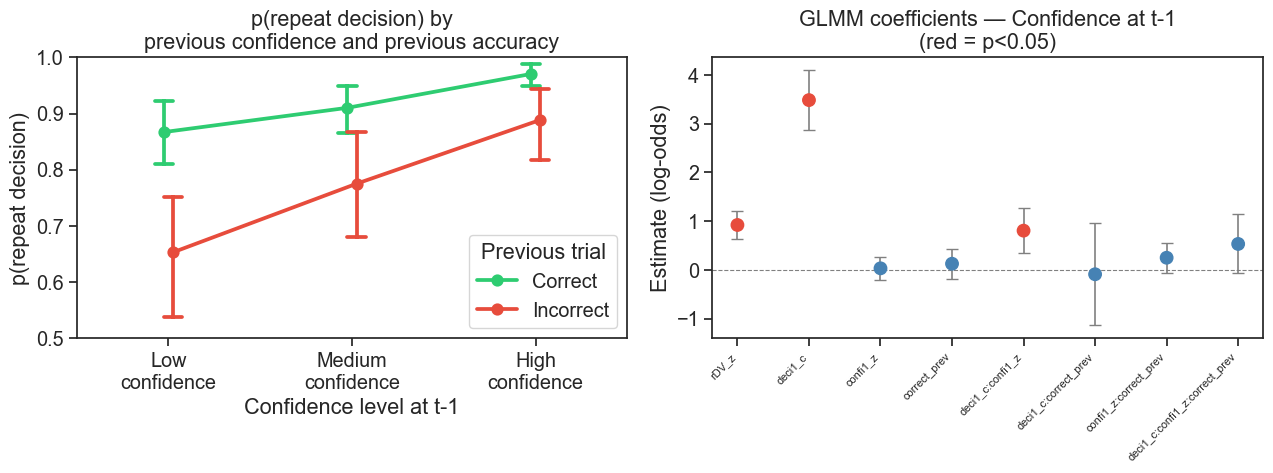

In [122]:
# ── Cell 23: Plot Trial-by-trial Metacognition ────────────────────────────────
df_meta_trial["confi1_bin"] = pd.qcut(
    df_meta_trial["confi-1"], q=3,
    labels=["Low\nconfidence", "Medium\nconfidence", "High\nconfidence"])
df_meta_trial["p_repeat"]  = 1 - df_meta_trial["switch"]
df_meta_trial["prev_label"] = df_meta_trial["correct_prev"].map(
    {1.0: "Correct", 0.0: "Incorrect"})
avg_meta = df_meta_trial.groupby(
    ["subj", "confi1_bin", "prev_label"], as_index=False
)["p_repeat"].mean()
coefs_mt_plot = coefs_mt_pd[coefs_mt_pd["term"] != "(Intercept)"].copy()
colors_mt     = ["#e74c3c" if p < 0.05 else "steelblue" for p in coefs_mt_plot["p_value"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.pointplot(
    data=avg_meta, x="confi1_bin", y="p_repeat",
    hue="prev_label", dodge=True, capsize=0.1,
    palette={"Correct": "#2ecc71", "Incorrect": "#e74c3c"},
    ax=axes[0]
)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("p(repeat decision) by\nprevious confidence and previous accuracy")
axes[0].set_xlabel("Confidence level at t-1")
axes[0].set_ylabel("p(repeat decision)")
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(title="Previous trial")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].errorbar(
    x=range(len(coefs_mt_plot)),
    y=coefs_mt_plot["estimate"],
    yerr=[coefs_mt_plot["estimate"] - coefs_mt_plot["conf_low"],
          coefs_mt_plot["conf_high"] - coefs_mt_plot["estimate"]],
    fmt="none", color="gray", capsize=4, linewidth=1.2, zorder=1
)
axes[1].scatter(range(len(coefs_mt_plot)), coefs_mt_plot["estimate"],
                color=colors_mt, s=80, zorder=2)
axes[1].set_xticks(range(len(coefs_mt_plot)))
axes[1].set_xticklabels(coefs_mt_plot["term"], rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Estimate (log-odds)")
axes[1].set_title("GLMM coefficients — Confidence at t-1\n(red = p<0.05)")
plt.tight_layout()
plt.show()

Previous response: Correct | nrep=0: β=-0.2213  p=0.0000
Previous response: Correct | nrep=1: β=-0.0740  p=0.3846
Previous response: Correct | nrep=2: β=+0.0208  p=0.8369
Previous response: Incorrect | nrep=0: β=-0.2213  p=0.0000
Previous response: Incorrect | nrep=1: β=+0.0919  p=0.3501
Previous response: Incorrect | nrep=2: β=-0.1570  p=0.2552


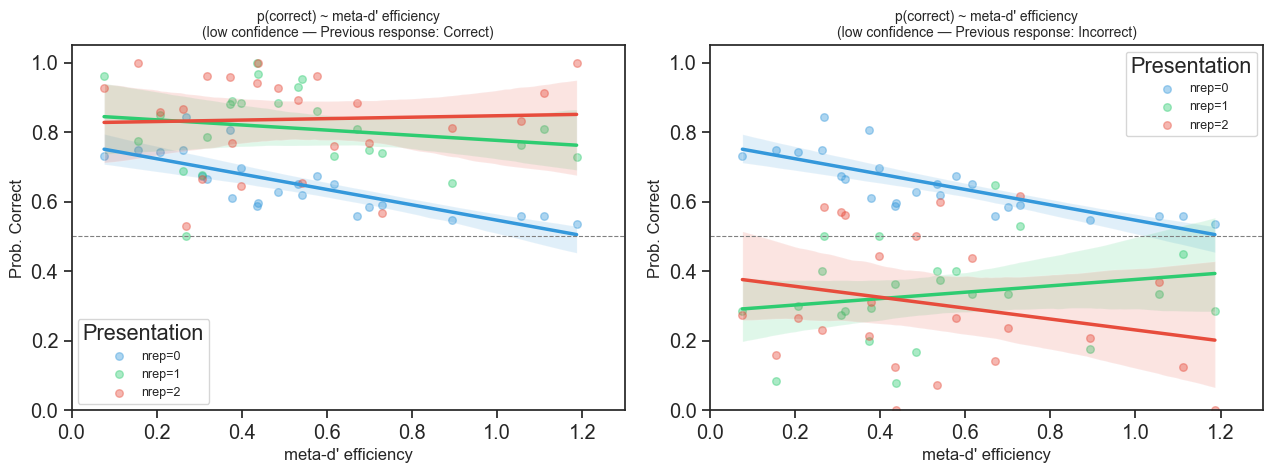

In [123]:
# ── Cell 24a: meta-d' Efficiency — low confidence, all nrep ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0", 1: "nrep=1", 2: "nrep=2"}
for correct_val, ax, title in zip(
    [1.0, 0.0], axes,
    ["Previous response: Correct", "Previous response: Incorrect"]
):
    for nrep_val, color in palette_nrep.items():
        df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
        df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
        df_nrep = df_nrep.dropna(subset=["correct", "correct_prev", "metad"]).reset_index(drop=True)
        df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")
        median_confi = df_nrep.groupby("subj")["confi"].transform("median")
        df_nrep_low  = df_nrep[df_nrep["confi"] < median_confi].copy()
        if nrep_val == 0:
            df_plot = df_nrep_low.copy()
        else:
            df_plot = df_nrep_low[df_nrep_low["correct_prev"] == correct_val].copy()
        by_subj = df_plot.groupby(
            ["subj", "metad_eff"], as_index=False
        )["correct"].mean()
        if len(by_subj) < 3:
            continue
        sns.regplot(
            data=by_subj, x="metad_eff", y="correct",
            color=color, scatter=True, ci=95, n_boot=1000,
            label=labels_nrep[nrep_val],
            scatter_kws={"alpha": 0.4, "s": 30},
            line_kws={"linewidth": 2.5}, ax=ax
        )
        slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
        print(f"{title} | {labels_nrep[nrep_val]}: β={slope:+.4f}  p={p:.4f}")
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("meta-d' efficiency", fontsize=12)
    ax.set_ylabel("Prob. Correct", fontsize=12)
    ax.set_title(f"p(correct) ~ meta-d' efficiency\n(low confidence — {title})", fontsize=10)
    ax.legend(title="Presentation", fontsize=9)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(0.0, 1.3)
plt.tight_layout()
plt.show()

Previous response: Correct | nrep=0: β=+0.1327  p=0.0013
Previous response: Correct | nrep=1: β=+0.0474  p=0.1527
Previous response: Correct | nrep=2: β=+0.0564  p=0.0418
Previous response: Incorrect | nrep=0: β=+0.1327  p=0.0013
Previous response: Incorrect | nrep=1: β=+0.0569  p=0.6218
Previous response: Incorrect | nrep=2: β=-0.1623  p=0.1424


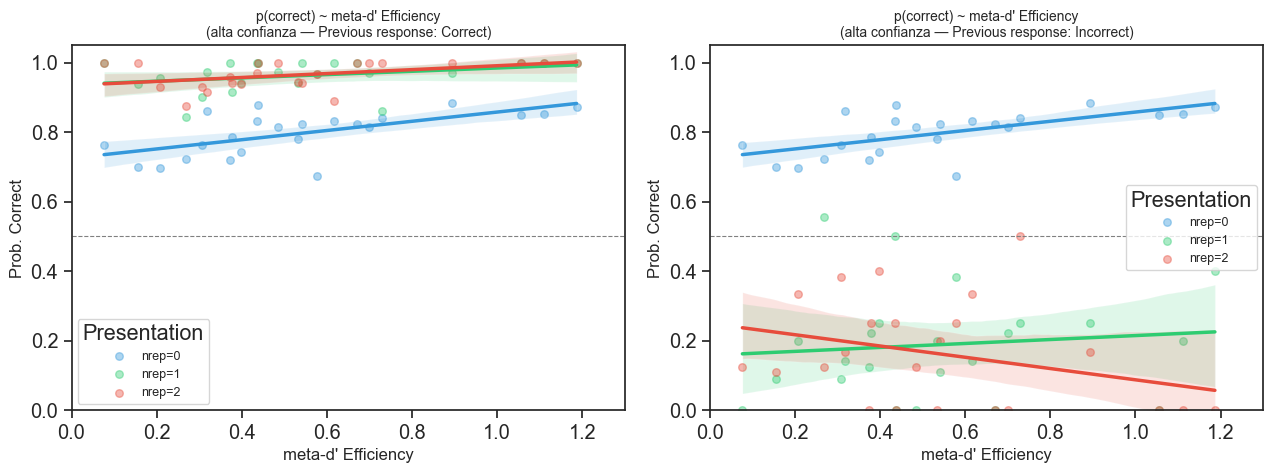

In [124]:
# ── Cell 24b: meta-d' Efficiency — high confidence, all nrep ────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette_nrep = {0: "#3498db", 1: "#2ecc71", 2: "#e74c3c"}
labels_nrep  = {0: "nrep=0", 1: "nrep=1", 2: "nrep=2"}

for correct_val, ax, title in zip(
    [1.0, 0.0], axes,
    ["Previous response: Correct", "Previous response: Incorrect"]
):
    for nrep_val, color in palette_nrep.items():
        df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
        df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
        df_nrep = df_nrep.dropna(subset=["correct", "correct_prev", "metad"]).reset_index(drop=True)
        df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")

        median_confi = df_nrep.groupby("subj")["confi"].transform("median")
        df_nrep_high = df_nrep[df_nrep["confi"] > median_confi].copy()

        if nrep_val == 0:
            df_plot = df_nrep_high.copy()
        else:
            df_plot = df_nrep_high[df_nrep_high["correct_prev"] == correct_val].copy()

        by_subj = df_plot.groupby(
            ["subj", "metad_eff"], as_index=False
        )["correct"].mean()

        if len(by_subj) < 3:
            continue

        sns.regplot(
            data=by_subj, x="metad_eff", y="correct",
            color=color, scatter=True, ci=95, n_boot=1000,
            label=labels_nrep[nrep_val],
            scatter_kws={"alpha": 0.4, "s": 30},
            line_kws={"linewidth": 2.5}, ax=ax
        )

        slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
        print(f"{title} | {labels_nrep[nrep_val]}: β={slope:+.4f}  p={p:.4f}")

    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("meta-d' Efficiency", fontsize=12)
    ax.set_ylabel("Prob. Correct", fontsize=12)
    ax.set_title(f"p(correct) ~ meta-d' Efficiency\n(alta confianza — {title})", fontsize=10)
    ax.legend(title="Presentation", fontsize=9)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(0.0, 1.3)

plt.tight_layout()
plt.show()

nrep=0 (all):  β=-0.2213  r=-0.773  p=0.0000
nrep=1 | Prev Correct  : β=-0.0740  r=-0.186  p=0.3846
nrep=1 | Prev Incorrect: β=+0.0919  r=+0.199  p=0.3501
nrep=2 | Prev Correct  : β=+0.0208  r=+0.044  p=0.8369
nrep=2 | Prev Incorrect: β=-0.1570  r=-0.242  p=0.2552


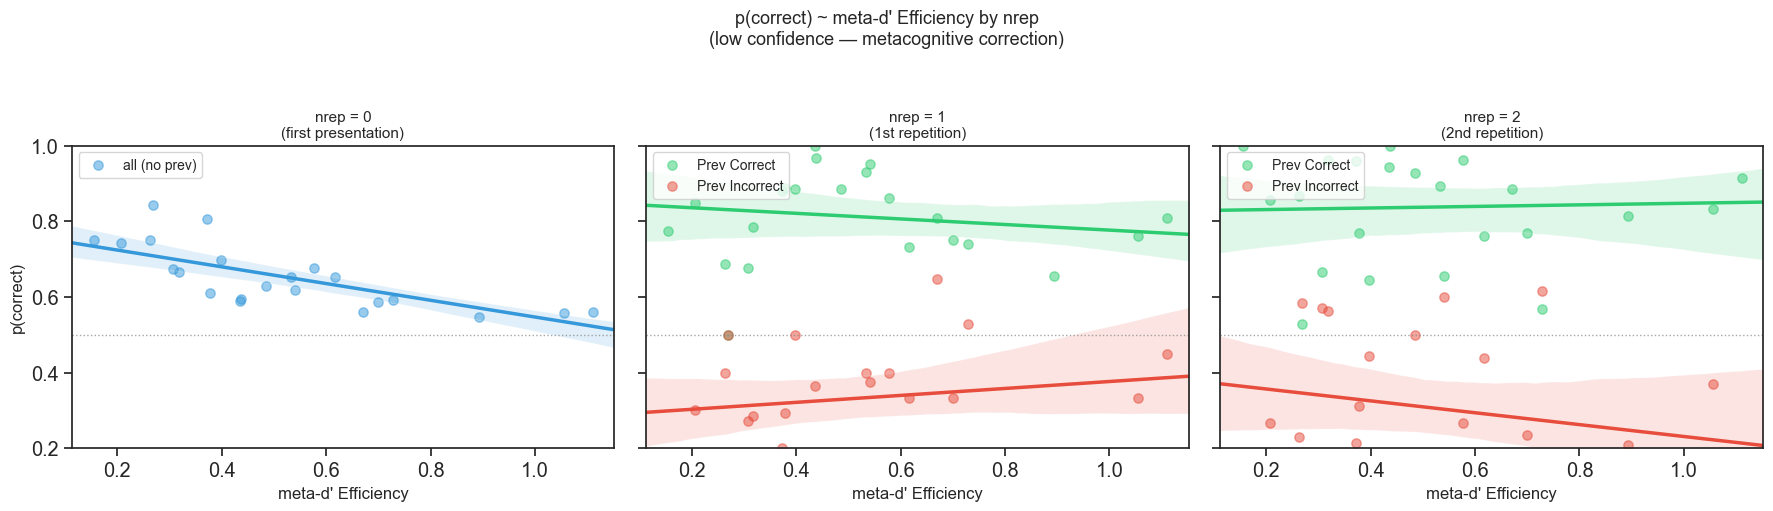

In [125]:
# ── Cell 24c: meta-d' Efficiency — low confidence, 3 panels (one per nrep) ──
# p(correct) ~ metad_efficiency split by previous trial outcome
# Low confidence only (confi < per participant median)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colors = {"Correct": "#2ecc71", "Incorrect": "#e74c3c"}
nrep_titles = {
    0: "nrep = 0\n(first presentation)",
    1: "nrep = 1\n(1st repetition)",
    2: "nrep = 2\n(2nd repetition)",
}

_x = eff_df["metad_eff"].replace([np.inf, -np.inf], np.nan).dropna()
x_lo = np.percentile(_x, 2)
x_hi = np.percentile(_x, 98)

for nrep_val, ax in zip([0, 1, 2], axes):
    df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
    df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
    df_nrep = df_nrep.dropna(subset=["correct", "metad"]).reset_index(drop=True)
    df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")

    median_confi = df_nrep.groupby("subj")["confi"].transform("median")
    df_low = df_nrep[df_nrep["confi"] < median_confi].copy()

    if nrep_val == 0:
        by_subj = df_low.groupby(["subj", "metad_eff"], as_index=False)["correct"].mean()
        if len(by_subj) >= 3:
            sns.regplot(data=by_subj, x="metad_eff", y="correct",
                        color="#3498db", scatter=True, ci=95, n_boot=1000,
                        truncate=True, label="all (no prev)",
                        scatter_kws={"alpha": 0.5, "s": 45},
                        line_kws={"linewidth": 2.5}, ax=ax)
            slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
            print(f"nrep=0 (all):  β={slope:+.4f}  r={r:+.3f}  p={p:.4f}")
    else:
        df_low = df_low.dropna(subset=["correct_prev"])
        for label, color in colors.items():
            prev_val = 1.0 if label == "Correct" else 0.0
            d = df_low[df_low["correct_prev"] == prev_val].copy()
            by_subj = d.groupby(["subj", "metad_eff"], as_index=False)["correct"].mean()
            if len(by_subj) < 3:
                continue
            sns.regplot(data=by_subj, x="metad_eff", y="correct",
                        color=color, scatter=True, ci=95, n_boot=1000,
                        truncate=True, label=f"Prev {label}",
                        scatter_kws={"alpha": 0.5, "s": 45},
                        line_kws={"linewidth": 2.5, "linestyle": "-"},
                        ax=ax)
            slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
            print(f"nrep={nrep_val} | Prev {label:<9}: β={slope:+.4f}  r={r:+.3f}  p={p:.4f}")

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0.2, 1.0)
    ax.set_xlabel("meta-d' Efficiency", fontsize=12)
    ax.set_ylabel("p(correct)" if nrep_val == 0 else "", fontsize=12)
    ax.set_title(nrep_titles[nrep_val], fontsize=11)
    ax.legend(fontsize=10, loc="upper left")

fig.suptitle(
    "p(correct) ~ meta-d' Efficiency by nrep\n"
    "(low confidence — metacognitive correction)",
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.show()


nrep=0 (all):  β=-0.0232  r=-0.336  p=0.1082
nrep=1 | Prev Correct  : β=+0.0106  r=+0.049  p=0.8213
nrep=1 | Prev Incorrect: β=+0.1172  r=+0.253  p=0.2324
nrep=2 | Prev Correct  : β=+0.0377  r=+0.149  p=0.4877
nrep=2 | Prev Incorrect: β=-0.1322  r=-0.243  p=0.2534


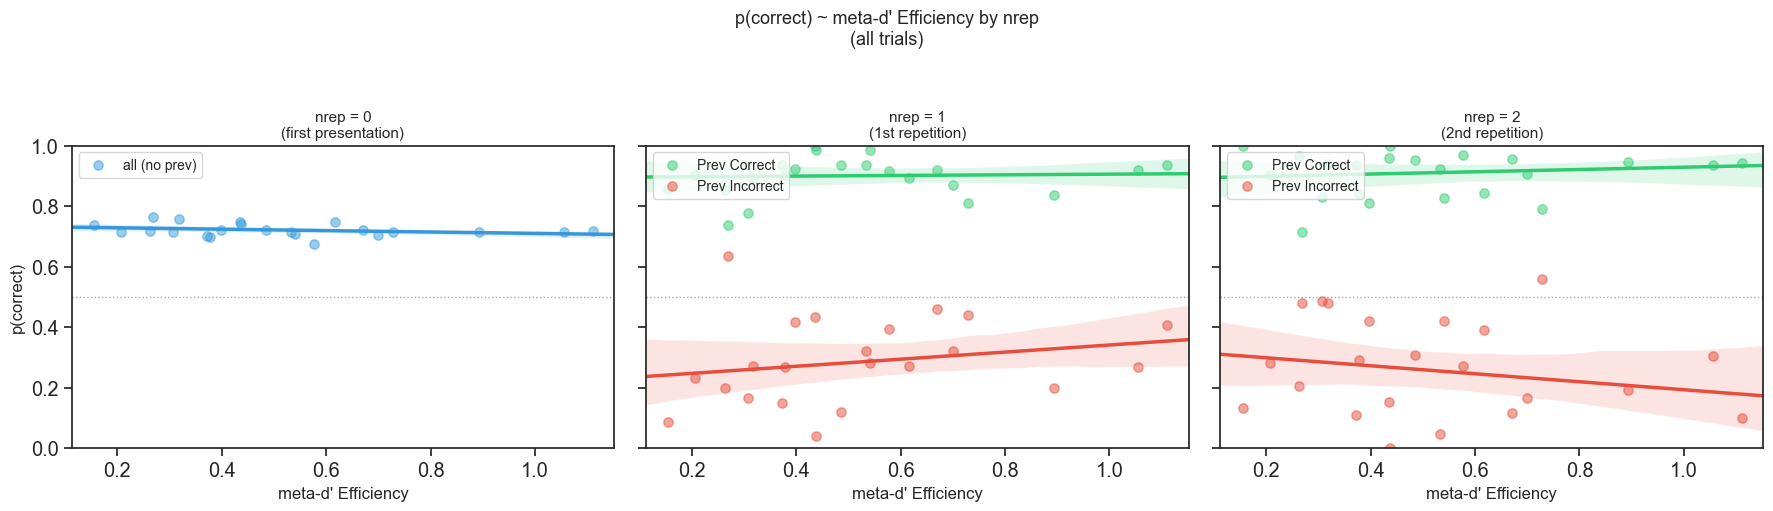

In [126]:
# ── Cell 24d: meta-d' Efficiency — all trials, 3 panels (one per nrep) ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colors = {"Correct": "#2ecc71", "Incorrect": "#e74c3c"}
nrep_titles = {
    0: "nrep = 0\n(first presentation)",
    1: "nrep = 1\n(1st repetition)",
    2: "nrep = 2\n(2nd repetition)",
}

_x = eff_df["metad_eff"].replace([np.inf, -np.inf], np.nan).dropna()
x_lo = np.percentile(_x, 2)
x_hi = np.percentile(_x, 98)

for nrep_val, ax in zip([0, 1, 2], axes):
    df_nrep = df_rt[df_rt["nrep"] == nrep_val].copy()
    df_nrep["correct_prev"] = df_nrep["correct-1"].astype(float)
    df_nrep = df_nrep.dropna(subset=["correct", "metad"]).reset_index(drop=True)
    df_nrep = df_nrep.merge(eff_df[["subj", "metad_eff"]], on="subj")

    if nrep_val == 0:
        by_subj = df_nrep.groupby(["subj", "metad_eff"], as_index=False)["correct"].mean()
        if len(by_subj) >= 3:
            sns.regplot(data=by_subj, x="metad_eff", y="correct",
                        color="#3498db", scatter=True, ci=95, n_boot=1000,
                        truncate=True, label="all (no prev)",
                        scatter_kws={"alpha": 0.5, "s": 45},
                        line_kws={"linewidth": 2.5}, ax=ax)
            slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
            print(f"nrep=0 (all):  β={slope:+.4f}  r={r:+.3f}  p={p:.4f}")
    else:
        df_nrep = df_nrep.dropna(subset=["correct_prev"])
        for label, color in colors.items():
            prev_val = 1.0 if label == "Correct" else 0.0
            d = df_nrep[df_nrep["correct_prev"] == prev_val].copy()
            by_subj = d.groupby(["subj", "metad_eff"], as_index=False)["correct"].mean()
            if len(by_subj) < 3:
                continue
            sns.regplot(data=by_subj, x="metad_eff", y="correct",
                        color=color, scatter=True, ci=95, n_boot=1000,
                        truncate=True, label=f"Prev {label}",
                        scatter_kws={"alpha": 0.5, "s": 45},
                        line_kws={"linewidth": 2.5, "linestyle": "-"},
                        ax=ax)
            slope, intercept, r, p, se = stats.linregress(by_subj["metad_eff"], by_subj["correct"])
            print(f"nrep={nrep_val} | Prev {label:<9}: β={slope:+.4f}  r={r:+.3f}  p={p:.4f}")

    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0.0, 1.0)
    ax.set_xlabel("meta-d' Efficiency", fontsize=12)
    ax.set_ylabel("p(correct)" if nrep_val == 0 else "", fontsize=12)
    ax.set_title(nrep_titles[nrep_val], fontsize=11)
    ax.legend(fontsize=10, loc="upper left")

fig.suptitle(
    "p(correct) ~ meta-d' Efficiency by nrep\n"
    "(all trials)",
    fontsize=13, y=1.03
)
plt.tight_layout()
plt.show()
